# ARIMAX

In [ ]:
# import potrebnych kniznic a konfiguracia notebooku

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from pmdarima import auto_arima

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import arimax_functions
importlib.reload(arimax_functions)
from arimax_functions import forward_selection, evaluate_forecast_rolling

import cred
from cred import DATA_PATH_CRED

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Importy uspesne.")


Importy uspesne.


In [ ]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TARGET_VAR = "pp_sa_ca_jd"
TEST_SIZE = 24

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()
df.drop(columns=["pp_nonsa","pp_sa_orig"], inplace = True)

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")

df_exog = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_EXOG)
df_exog = df_exog.set_index("datum").sort_index()
df_exog = df_exog.asfreq("MS")
df_exog = df_exog.drop(columns=["datum"], errors="ignore")

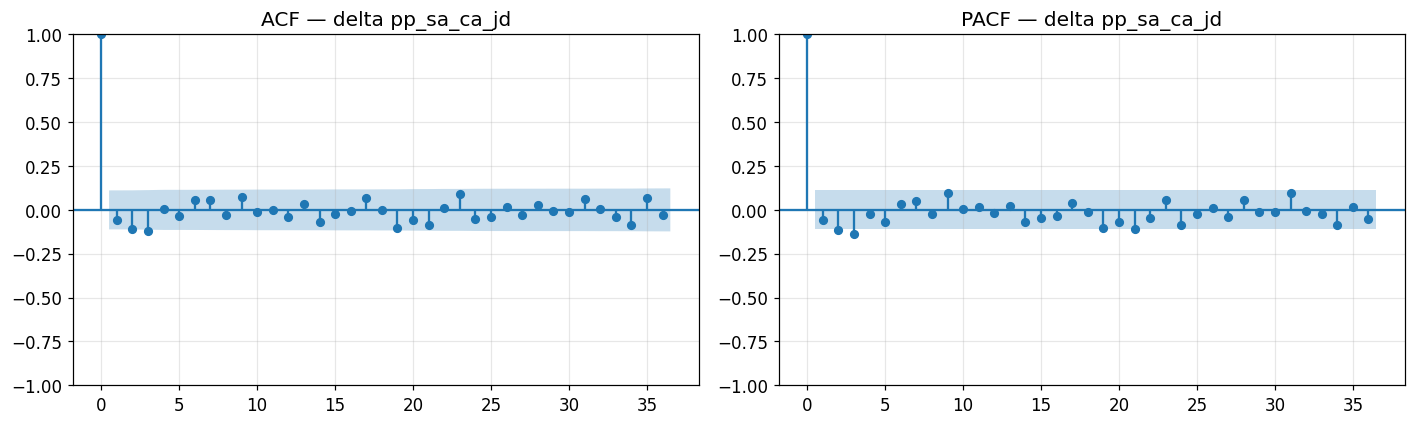

In [45]:
# identifikacia poctu lagov
# ACF => MA (q)
# PACF => AR (p)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df[TARGET_VAR], lags=36, ax=axes[0], title="ACF — delta pp_sa_ca_jd")
plot_pacf(df[TARGET_VAR], lags=36, ax=axes[1], title="PACF — delta pp_sa_ca_jd")
plt.tight_layout()
plt.show()


In [46]:
# vyber premennych do modelu na zaklade znizovania BIC
selected_cols = forward_selection(df,TARGET_VAR)

BIC forward selection:
--------------------------------------------------
  + 'export_celkovy_sa'  BIC = 1516.71
  + 'crisis_dummy'  BIC = 1438.52
  + 'trzby_priemysel_sa'  BIC = 1416.06
  + 'economic_sentiment'  BIC = 1414.83
  Zastavenie — pridanie ziadnej premennej nezlepsuje BIC.
--------------------------------------------------
Vybrane premenne: ['export_celkovy_sa', 'crisis_dummy', 'trzby_priemysel_sa', 'economic_sentiment']
Finalny BIC    : 1414.83


In [5]:
# korelacna matica vybranych premennych
df[selected_cols + [TARGET_VAR]].corr()

,export_celkovy_sa,crisis_dummy,trzby_priemysel_sa,economic_sentiment,pp_sa_ca_jd
export_celkovy_sa,1.000000,0.079359,0.737235,0.359702,0.605090
crisis_dummy,0.079359,1.000000,0.064610,0.008946,-0.290359
trzby_priemysel_sa,0.737235,0.064610,1.000000,0.251193,0.632102
economic_sentiment,0.359702,0.008946,0.251193,1.000000,0.284182
pp_sa_ca_jd,0.605090,-0.290359,0.632102,0.284182,1.000000


In [47]:
# urcenie rozsah testovacej mnoziny a rozdelenie dat na train/test
X = df[selected_cols]
y = df[TARGET_VAR]

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print(f"Trenovacia mnozina: {y_train.index.min().date()} az {y_train.index.max().date()} ({len(y_train)} obs.)")
print(f"Testovacia mnozina: {y_test.index.min().date()} az {y_test.index.max().date()} ({len(y_test)} obs.)")


Trenovacia mnozina: 2000-02-01 az 2023-12-01 (287 obs.)
Testovacia mnozina: 2024-01-01 az 2025-12-01 (24 obs.)


In [48]:
arimax_model = auto_arima(
    y=y_train,
    X=X_train,

    d=0,
    stationary=True,

    seasonal=False,
    m=1,

    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,

    information_criterion="bic",
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : BIC=1335.687, Time=0.13 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : BIC=1320.796, Time=0.30 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : BIC=1321.597, Time=0.22 sec
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=1330.264, Time=0.26 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : BIC=1326.046, Time=0.42 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : BIC=1326.167, Time=0.44 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : BIC=1332.631, Time=0.63 sec
 ARIMA(1,0,0)(0,0,0)[0]             : BIC=1315.416, Time=0.23 sec
 ARIMA(2,0,0)(0,0,0)[0]             : BIC=1320.687, Time=0.31 sec
 ARIMA(1,0,1)(0,0,0)[0]             : BIC=1320.780, Time=0.36 sec
 ARIMA(0,0,1)(0,0,0)[0]             : BIC=1316.216, Time=0.26 sec
 ARIMA(2,0,1)(0,0,0)[0]             : BIC=1326.486, Time=0.49 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 4.070 seconds


In [19]:
print(arimax_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  287
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -640.729
Date:                Wed, 16 Sep 2026   AIC                           1293.459
Time:                        21:15:23   BIC                           1315.416
Sample:                    02-01-2000   HQIC                          1302.259
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
export_celkovy_sa      0.0055      0.001      7.176      0.000       0.004       0.007
crisis_dummy         -21.3943      5.457     -3.921      0.000     -32.089     -10.699
trzby_priemysel_sa  

In [49]:
# odhad modelu
BASE_ORDER = (1,0,0)
SEAS_ORDER = (0, 0, 0,12)

model_fit = SARIMAX(
    y_train,
    exog              = X_train,
    order             = BASE_ORDER,
    seasonal_order    = SEAS_ORDER,
    enforce_stationarity  = False,
    enforce_invertibility = False,
).fit(disp=False, cov_type="robust")

print(model_fit.summary()) 


                               SARIMAX Results                                
Dep. Variable:            pp_sa_ca_jd   No. Observations:                  287
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -638.747
Date:                Wed, 16 Sep 2026   AIC                           1289.493
Time:                        21:58:14   BIC                           1311.429
Sample:                    02-01-2000   HQIC                          1298.286
                         - 12-01-2023                                         
Covariance Type:               robust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
export_celkovy_sa      0.0055      0.001      5.166      0.000       0.003       0.008
crisis_dummy         -21.3941      0.934    -22.917      0.000     -23.224     -19.564
trzby_priemysel_sa  

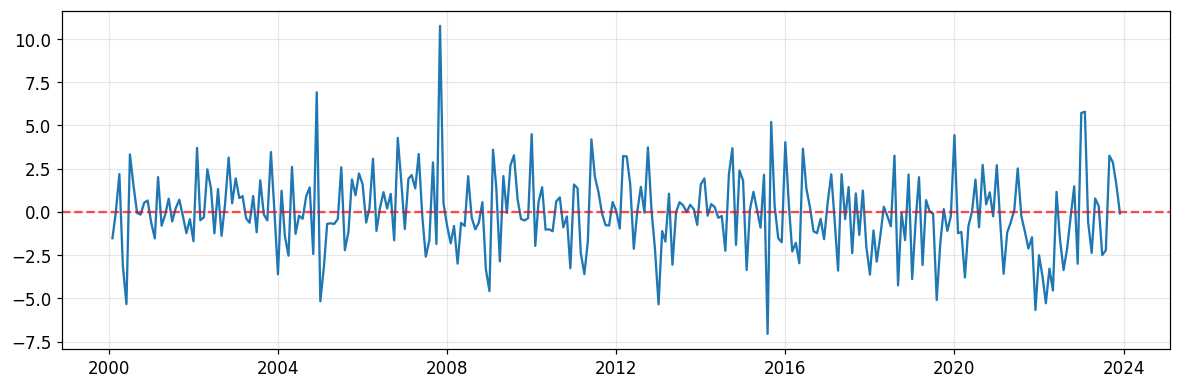

In [26]:
# vizualizacia rezidualov modelu
plt.plot(model_fit.resid)
plt.axhline(y = 0, color = "red", linestyle = "--", alpha = 0.7)

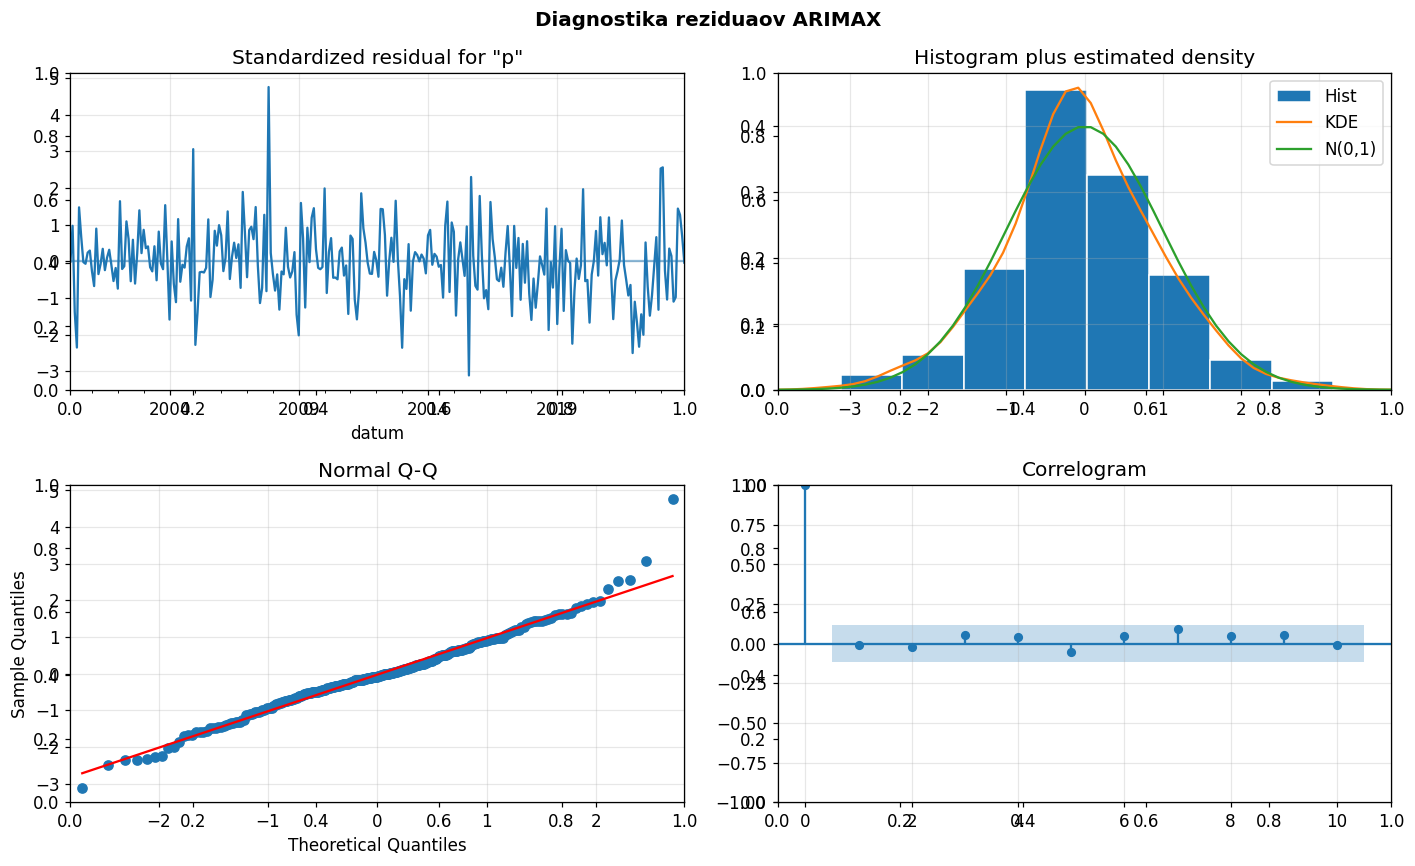

In [29]:
# diagnostika rezidualov
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
model_fit.plot_diagnostics(fig=fig)
plt.suptitle("Diagnostika reziduaov ARIMAX", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [50]:
df_exog_lag1 = df_exog.copy().shift(1)

df_arimax_eval = pd.concat(
    [
        df[TARGET_VAR].rename(TARGET_VAR),
        df_exog_lag1
    ],
    axis=1
).replace([np.inf, -np.inf], np.nan).dropna()

data_diff_eval = df_arimax_eval[TARGET_VAR]
exog_eval = df_arimax_eval.drop(columns=TARGET_VAR)

level_series_eval = df_pp[TARGET_VAR].loc[data_diff_eval.index]

initial_train_size_eval = len(data_diff_eval) - TEST_SIZE

last_train_value_eval = df_pp[TARGET_VAR].loc[
    data_diff_eval.index[initial_train_size_eval - 1]
]

results, models = evaluate_forecast_rolling(
    data_diff=data_diff_eval,
    exog=exog_eval,
    initial_train_size=initial_train_size_eval,
    order=BASE_ORDER,
    last_train_value=last_train_value_eval,
    level_series=level_series_eval
)

C:\Users\adamv\AppData\Local\Temp\ipykernel_5684\1780960371.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_arimax_eval = pd.concat(


RMSE (diferencia): 3.1202
RMSE (level, onestep rekonstrukcia): 3.1202
MAPE (level): 2.57%
ME (level): -1.8322


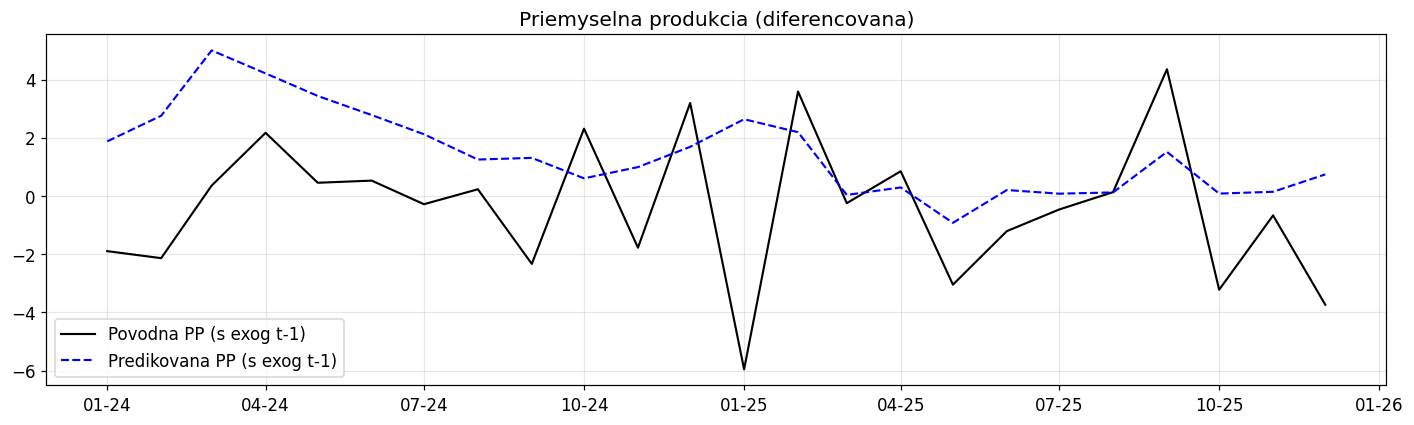

In [51]:
fig, ax = plt.subplots()
ax.plot(results.index, results["actual_diff"], color= "black", linewidth = 1.4, label = "Povodna PP (s exog t-1)")
ax.plot(results.index, results["predicted_diff"], color= "blue", linestyle='--', linewidth = 1.4, label = "Predikovana PP (s exog t-1)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia (diferencovana)")
ax.legend()
plt.tight_layout()
plt.show()

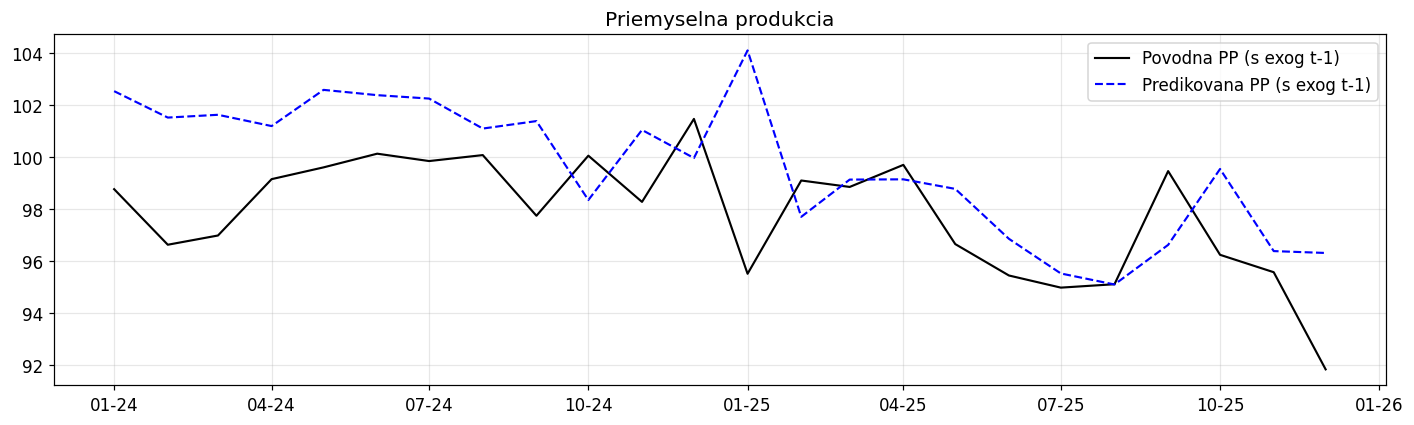

In [52]:
fig, ax = plt.subplots()
ax.plot(results.index, results["actual_level"], color= "black", linewidth = 1.4, label = "Povodna PP (s exog t-1)")
ax.plot(results.index, results["predicted_level"], color= "blue", linestyle='--', linewidth = 1.4, label = "Predikovana PP (s exog t-1)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia")
ax.legend()
plt.tight_layout()
plt.show()

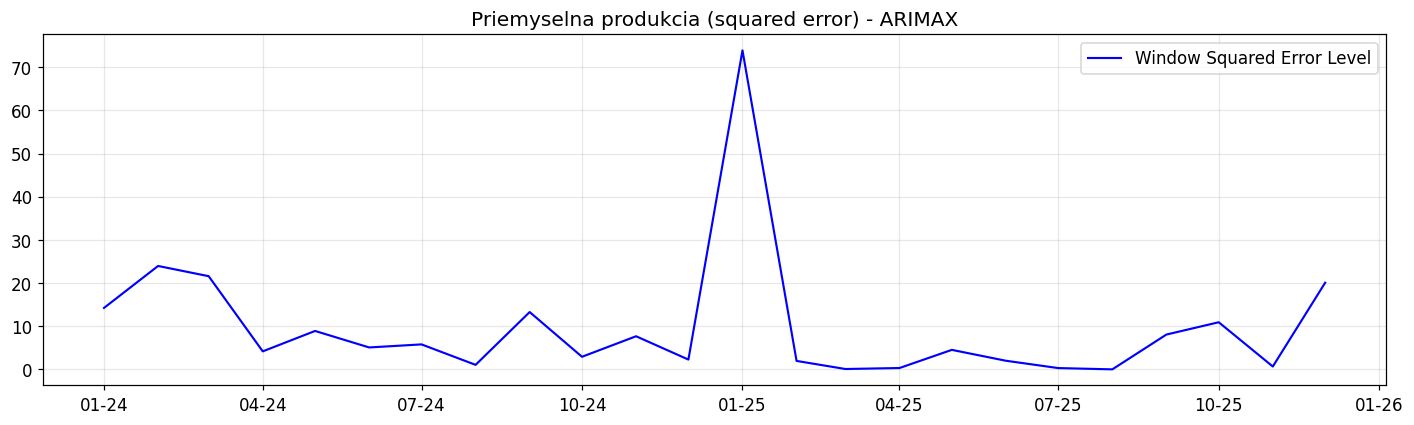

In [54]:
fig, ax = plt.subplots()
ax.plot(results.index, results["sq_error_level"], color= "blue", linewidth = 1.4, label = "Window Squared Error Level")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia (squared error) - ARIMAX")
ax.legend()
plt.tight_layout()
plt.show()